In [1]:
from utils import * 
import json 
from Bio.Align import PairwiseAligner
from fasta import FASTAFile
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
import networkx as nx
 
# bz_0_host_genome_id = 'SR-VP_Bioreactor_ck_bot_05_17_2025_Black_host_Methanoperedens_44_40'

%load_ext autoreload 
%autoreload 2

DATA_DIR = '../data/sr-vp'

# Note that when making the lists, matching annotations which contain only "rps3" results in false positives, as some proteins have descriptions which describe rps3-based 
# taxonomy are also flagged, e.g. "...organism_desc=Sibling to OP3 based on rpS3."

In [2]:
def load_coverm(path:str):
    '''coverm data has a column per sample and per metric. Columns are of the form {reads_path} {metric}.'''
    metrics = ['Trimmed Mean', 'Mean',  'Covered Bases', 'Covered Fraction', 'Variance', 'Read Count', 'RPKM', 'TPM', 'Length']
    column_pattern = r'(?P<sample_id>[A-Za-z0-9_]+) (?P<metric>.+)$'
    
    df = pd.read_csv(path, sep='\t')
    df = df.rename(columns={'Contig':'contig_id'})
    df = df.melt(id_vars='contig_id', var_name='column', value_name='value').reset_index()
    df = pd.concat([df.drop(columns=['column']).copy(), df['column'].str.extract(column_pattern)], axis=1)
    df = df[df.metric.isin(metrics)].copy() # Some weirdness with duplicate columns (e.g. Mean.1) being created, not sure why. 
    df['metric'] = df['metric'].apply(lambda metric : metric.replace(' ', '_').lower())
    df = df.pivot(values='value', columns='metric', index=['contig_id', 'sample_id']).reset_index()
    df.columns.name = ''
    return df

In [3]:
# Want to look at co-occurrence patterns of the two Betazoids we have in the SR-VP samples. 

# First need to look at what Methanoperedens are present. We have 77 complete and partial genomes https://ggkbase.berkeley.edu/MpSRVP/organisms
SRVP_SAMPLE_METADATA_DF = pd.read_csv('../data/sr-vp/sample_metadata.csv')
SRVP_SAMPLE_METADATA_DF = SRVP_SAMPLE_METADATA_DF[SRVP_SAMPLE_METADATA_DF.regime == 'Illumina'].copy()


In [4]:
def load_ggkbase_fasta(path:str):
    df = FASTAFile.from_file(path).to_df()
    df['project_id'] = [id_.split('|')[2] for id_ in df.index]
    df['gene_id'] = [id_.split('|')[0] for id_ in df.index]
    df['bin_id'] = [id_.split('|')[1] for id_ in df.index]
    df = df.set_index('gene_id')
    return df

In [5]:
# I don't necessarily trust the taxonomy assignments on ggKbase, particularly because they are not particulary detailed or standardized. 
# Instead, I did the following:
#   (1) Obtained all SR-VP rps3 nucleotide sequences assigned as archaeal, unkown, or eukaryotic using ggKbase lists (./data/archaea_rps3.fna). 
#   (2) Obtained all archaeal marker genes in the TIGR01008.fna file from the latest GTDB release (under genomic_files_all/ar53_marker_genes_all.tar.gz). 
#       The ID of each sequence is its corresponding genome. 
#   (3) Constructed a BLAST nucleotide database on biotite using the GTDB genes (n=20119). 
#   (4) Ran BLASTn against the GTDB database on biotite. blastn
#        -db /home/philippar/db/gtdb_archaea_rps3 -out archaea_rps3_blast-gtdb_archaea_rps3.tsv -query /home/philippar/betazoid/sr-vp/archaea_rps3.fna -outfmt "6 qseqid sseqid pident length evalue bitscore qstart qend sstart send" -max_hsps 1 -max_target_seqs 50
#   (5) Used the strongest BLASTn hit from GTDB to assign taxonomy to each rps3 sequence.  


In [43]:
archaea_rps3_df = load_ggkbase_fasta('../data/sr-vp/archaea_rps3.fna') # Obtained using the ggKbase lists utility, filtered for Archaeal and unknown taxonomy.
mp_srvp_rps3_df = load_ggkbase_fasta('../data/sr-vp/MpSRVP_rps3.faa')

print('Number of rps3 sequences assigned Archaeal or unknown taxonomy in SR-VP samples:', archaea_rps3_df.index.nunique())
print('Number of rps3 sequences identified in the MpSRVP project:', mp_srvp_rps3_df.index.nunique())
print('Number of rps3 sequences in the MpSRVP project assigned archaeal, unknown, or eukaryotic taxonomy:', mp_srvp_rps3_df.index.isin(archaea_rps3_df.index.values).sum())


Number of rps3 sequences assigned Archaeal or unknown taxonomy in SR-VP samples: 6793
Number of rps3 sequences identified in the MpSRVP project: 62
Number of rps3 sequences in the MpSRVP project assigned archaeal, unknown, or eukaryotic taxonomy: 62


In [44]:
BLAST_FIELDS = ['gene_id', 'subject_gene_id', 'percent_identity', 'alignment_length', 'e_value', 'bit_score', 'query_start', 'query_end', 'subject_start', 'subject_end']
GTDB_TAXONOMY_PATTERN = r'd__(?P<domain>[^;]+);p__(?P<phylum>[^;]+);c__(?P<class>[^;]+);o__(?P<order>[^;]+);f__(?P<family>[^;]+);g__(?P<genus>[^;]+);s__(?P<species>[^$]+)'

archaea_rps3_blast_df = pd.read_csv('../data/sr-vp/archaea_rps3_blast-gtdb_archaea_rps3.tsv', sep='\t', names=BLAST_FIELDS)
archaea_rps3_blast_df['gene_id'] = [gene_id.split('|')[0] for gene_id in archaea_rps3_blast_df.gene_id]
archaea_rps3_blast_df['subject_genome_id'] = archaea_rps3_blast_df.subject_gene_id
archaea_rps3_blast_df['subject_taxonomy'] = archaea_rps3_blast_df.subject_genome_id.map(pd.read_csv('../data/sr-vp/gtdb_archaea_taxonomy.tsv', sep='\t', index_col=0, names=['taxonomy']).taxonomy)
archaea_rps3_blast_df = pd.concat([archaea_rps3_blast_df, archaea_rps3_blast_df.subject_taxonomy.str.extract(GTDB_TAXONOMY_PATTERN)], axis=1)
archaea_rps3_blast_df = archaea_rps3_blast_df.sort_values('bit_score', ascending=False).copy() # So when duplicates are dropped, the strongest hit is retained.

filters = dict()
filters['short_alignment'] = archaea_rps3_blast_df.alignment_length < 100
filters['low_percent_identity'] = archaea_rps3_blast_df.percent_identity < 80 

archaea_rps3_blast_df = apply_filters(filters, archaea_rps3_blast_df)
assert np.all(mp_srvp_rps3_df.index.isin(archaea_rps3_blast_df.gene_id)), 'Methanoperedens from the MpSRVP project are not represented in the filtered BLAST output.'

taxonomy_cols = ['domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'percent_identity']
archaea_rps3_df = archaea_rps3_df.drop(columns=taxonomy_cols, errors='ignore')
archaea_rps3_df = archaea_rps3_df.merge(archaea_rps3_blast_df.drop_duplicates('gene_id').set_index('gene_id')[taxonomy_cols], how='left', left_index=True, right_index=True)
archaea_rps3_df['contig_id'] = ['_'.join(id_.split('_')[:-1]) for id_ in archaea_rps3_df.index]
archaea_rps3_df['has_blast_hit'] = archaea_rps3_df.index.isin(archaea_rps3_blast_df.gene_id.unique())
archaea_rps3_df['in_mp_srvp'] = archaea_rps3_df.index.isin(mp_srvp_rps3_df.index.values)
archaea_rps3_df['length'] = archaea_rps3_df.seq.apply(len)
assert np.all(mp_srvp_rps3_df.index.isin(archaea_rps3_blast_df.gene_id)), 'Methanoperedens from the MpSRVP project are not represented in the filtered BLAST output.'

filters = dict()
filters['not_methanoperedens'] = archaea_rps3_df.genus != 'Methanoperedens'
filters['partial_gene'] = archaea_rps3_df.seq.apply(len) < 600

mp_rps3_df = apply_filters(filters, archaea_rps3_df)

print('\nNumber of rps3 with a BLAST hit:', archaea_rps3_blast_df.gene_id.nunique())
print('Number of rps3 with no BLAST hits:', (~archaea_rps3_df.has_blast_hit).sum())
print('Number of Methanoperedens rps3:', len(mp_rps3_df))


apply_filters: 906 entries removed by short_alignment.
apply_filters: 30140 entries removed by low_percent_identity.
apply_filters: 6389 entries removed by not_methanoperedens.
apply_filters: 1276 entries removed by partial_gene.

Number of rps3 with a BLAST hit: 4041
Number of rps3 with no BLAST hits: 2752
Number of Methanoperedens rps3: 364


In [45]:
# To achieve slightly more robust taxonomy groups, I decided to extend the detected rps3 genes beyond the ORF boundaries. 
#   (1) Obtained the full contigs from the rps3 in mp_rps3_df from Shufei, along with the coverage and taxonomy (included in FASTA headers).
#   (2) Extended each rps3 gene beyond the ORF by between 100-500 bp, depending on the length of the source contig. 
#   (3) Used MMseqs to align and cluster all rps3 (for greater control over the clustering conditions). 
#   (4) Selected the longest representative sequence from each cluster and used bbmap to map reads, with the --ambiguous all flag. 

def load_mp_rps3_contigs(path:str='../data/sr-vp/mp_rps3_contigs.txt'):
    parse_header = lambda header : dict(zip(['id', 'contig_id', 'coverage', 'taxonomy'], header.split('|')))
    df = FASTAFile.from_file(path).to_df()
    df['description'] = df.index + df.description # The BioPython FASTA parser does not handle the descriptions correctly for this file. 
    df = df.reset_index(drop=True)
    df = pd.concat([df, pd.DataFrame.from_records(df.description.apply(parse_header))], axis=1)
    df['length'] = df.seq.apply(len)
    df = df.drop_duplicates('contig_id').set_index('contig_id')
    return df

mp_rps3_contigs_df = load_mp_rps3_contigs()
print('Minimum contig length:', mp_rps3_contigs_df.seq.apply(len).min())
print('Maximum contig length:', mp_rps3_contigs_df.seq.apply(len).max())

Minimum contig length: 1007
Maximum contig length: 4112728


In [ ]:
delta = 500

assert 'original_length' not in mp_rps3_df.columns, 'rps3 ORFs have already been extended.'

for row in tqdm(mp_rps3_df.itertuples(), desc='Extending sequences beyond rps3 ORF.'):
    contig = mp_rps3_contigs_df.loc[row.contig_id].seq

    match_ = re.search(row.seq, contig)
    if match_ is None:
        contig = reverse_complement(contig)
        match_ = re.search(row.seq, contig)

    start, end = match_.start(), match_.end()
    start = max(start - delta, 0)
    end = min(end + delta, len(contig))

    mp_rps3_df.loc[row.Index, 'original_length'] = len(row.seq)
    mp_rps3_df.loc[row.Index, 'seq'] = contig[start:end]
    mp_rps3_df.loc[row.Index, 'length'] = end - start
    mp_rps3_df.loc[row.Index,'left_extension_length'] = match_.start() - start 
    mp_rps3_df.loc[row.Index,'right_extension_length'] = end - match_.end()

FASTAFile.from_df(mp_rps3_df).write('../data/sr-vp/mp_rps3.fna')

In [47]:
print('Minimum extended ORF length:', mp_rps3_df.seq.apply(len).min())
print('Maximum extended ORF length:', mp_rps3_df.seq.apply(len).max())

# Commands for running on biotite. 
MMSEQS_DIR = '/home/philippar/mmseqs'
MMSEQS_SEARCH_FIELDS = 'query,target,fident,alnlen,qcov,tcov,qstart,qend,tstart,tend,qlen,tlen'
MMSEQS_DATABASE_NAME = 'mp_rps3'
MMSEQS_DATABASE_PATH = os.path.join(MMSEQS_DIR, 'db', MMSEQS_DATABASE_NAME)
MMSEQS_INPUT_PATH = '/home/philippar/mp_rps3.fna'

cmd = f'\nmmseqs createdb  {MMSEQS_INPUT_PATH} {MMSEQS_DATABASE_PATH} --dbtype 2'
cmd += f'\nmmseqs search {MMSEQS_DATABASE_PATH} {MMSEQS_DATABASE_PATH} {MMSEQS_DATABASE_PATH}.out /home/philippar/tmp/ --search-type 3'
cmd += f'\nmmseqs convertalis {MMSEQS_DATABASE_PATH} {MMSEQS_DATABASE_PATH} {MMSEQS_DATABASE_PATH}.out {MMSEQS_DIR}/{MMSEQS_DATABASE_NAME}.tsv --format-output {MMSEQS_SEARCH_FIELDS}'
print(cmd)

Minimum extended ORF length: 1007
Maximum extended ORF length: 1942

mmseqs createdb  /home/philippar/mp_rps3.fna /home/philippar/mmseqs/db/mp_rps3 --dbtype 2
mmseqs search /home/philippar/mmseqs/db/mp_rps3 /home/philippar/mmseqs/db/mp_rps3 /home/philippar/mmseqs/db/mp_rps3.out /home/philippar/tmp/ --search-type 3
mmseqs convertalis /home/philippar/mmseqs/db/mp_rps3 /home/philippar/mmseqs/db/mp_rps3 /home/philippar/mmseqs/db/mp_rps3.out /home/philippar/mmseqs/mp_rps3.tsv --format-output query,target,fident,alnlen,qcov,tcov,qstart,qend,tstart,tend,qlen,tlen


In [48]:
# Using mmseqs easy-cluster poduced similar results, but this allows a bit more control over which alignments justify clustering.

mp_rps3_align_df = pd.read_csv('../data/sr-vp/mp_rps3.tsv', sep='\t', names=MMSEQS_SEARCH_FIELDS.split(','))

print('Number of aligned contigs:', mp_rps3_align_df['query'].nunique())
print('Number of alignments:', len(mp_rps3_align_df), f'(out of {mp_rps3_align_df['query'].nunique() **2} possible alignments)')

# Want any alignment with coverage < 100% to be at the end of one of the two sequences. 
delta = 3
mask = (mp_rps3_align_df.qstart < delta) | (mp_rps3_align_df.tstart < delta)
mask = mask | ((mp_rps3_align_df.qlen - mp_rps3_align_df.qend) < delta)
mask = mask | ((mp_rps3_align_df.tlen - mp_rps3_align_df.tend) < delta)

filters = dict()
filters['low_sequence_identity'] = mp_rps3_align_df.fident < 0.99
filters['self_alignment'] = mp_rps3_align_df['query'] == mp_rps3_align_df['target']
filters['incomplete_alignment'] = ~mask

mp_rps3_align_df = apply_filters(filters, mp_rps3_align_df)
print('Minimum coverage after filtering:', min(mp_rps3_align_df.tcov.min(), mp_rps3_align_df.qcov.min()))

edges = set()
for row in mp_rps3_align_df.itertuples():
    edges.add(tuple(sorted([row.query, row.target])))
nodes = mp_rps3_df.index.values

graph = nx.Graph()
graph.add_nodes_from(nodes)
graph.add_edges_from(edges)

clusters = sorted(list(nx.connected_components(graph)), key=len)[::-1]
cluster_id_map = {gene_id:i for i, cluster in enumerate(clusters) for gene_id in cluster}
print('\nNumber of clusters:', len(clusters))
print('Number of singleton clusters:', sum([len(cluster) == 1 for cluster in clusters]))

mp_rps3_df['cluster_id'] = mp_rps3_df.index.map(cluster_id_map)
mp_rps3_df['length'] = mp_rps3_df.seq.apply(len)

mp_reps_rps3_df = mp_rps3_df.sort_values('length', ascending=False).drop_duplicates('cluster_id')
mp_reps_rps3_df['genome_id'] = [f'mp_{i}' for i in mp_reps_rps3_df.cluster_id]
mp_reps_rps3_df = mp_reps_rps3_df.reset_index(drop=False).set_index('genome_id')


Number of aligned contigs: 364
Number of alignments: 109200 (out of 132496 possible alignments)
apply_filters: 105153 entries removed by low_sequence_identity.
apply_filters: 364 entries removed by self_alignment.
apply_filters: 7798 entries removed by incomplete_alignment.
Minimum coverage after filtering: 0.366

Number of clusters: 115
Number of singleton clusters: 77


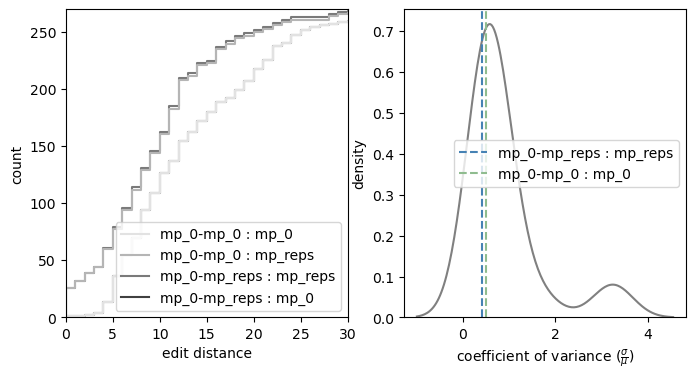

Where do the reads mapped to mp_0 in the mp_0_rps3 mapping get placed in the mp_reps_rps3 mapping?
mp_0	120
mp_37	78
mp_8	36
mp_17	27
mp_29	6


In [54]:
mp_rps3_df['genome_id'] = mp_rps3_df.cluster_id.apply(lambda cluster_id : f'mp_{cluster_id}')
mp_rps3_df['coverage'] = mp_rps3_df.contig_id.map(mp_rps3_contigs_df.coverage).astype(float)

coverm_df = coverm_dfs['mp_reps'].copy().rename(columns={'contig_id':'genome_id', 'trimmed_mean':'coverage'})
coverm_df['ggkbase_coverage'] = coverm_df.genome_id.map(mp_rps3_df[mp_rps3_df.project_id == 'SR-VP_Bioreactor_N_bot_05_17_2025'].set_index('genome_id').coverage)

coverm_df['coverage_diff'] = np.abs(coverm_df.coverage.astype(float) - coverm_df.ggkbase_coverage.astype(float))
coverm_df['coverage_diff_fraction'] = coverm_df.coverage_diff / coverm_df.coverage

print('Maximum difference between ggKbase and predicted coverages:', coverm_df.coverage_diff.max())
print('Maximum fractional difference between ggKbase and predicted coverages:', coverm_df.coverage_diff_fraction.max())
print('Mean difference between ggKbase and predicted coverages:', coverm_df.coverage_diff.mean())
print('Mean fractional difference between ggKbase and predicted coverages:', coverm_df.coverage_diff_fraction.mean())

# coverm_df[coverm_df.read_count > 0].sort_values('coverage', ascending=False).set_index('genome_id')[['read_count', 'coverage', 'coefficient_of_variance', 'ggkbase_coverage', 'coverage_diff']]

# Inspection of the coverage variance from the bowtie mapping suggests that there might be some problem with reads mapping to only one of many possible valid locations
# e.g. with mp_17, which has a CV of 1.16 and a coverage of >7x despite not being represented by a contig in the sample. To address this, I re-ran bowtie mapping with the -a
# option, so that all valid mappings are reported. The result (including secondary alignments), ended up with coverage values which differed more from ggKbase overall, 
# so I think sticking with only best mappings is a good idea. It could be that this approach is simply more sensitive to small taxonomical differences (which is what
# I wanted anyway).

Maximum difference between ggKbase and predicted coverages: 14.0
Maximum fractional difference between ggKbase and predicted coverages: inf
Mean difference between ggKbase and predicted coverages: 7.532119506999999
Mean fractional difference between ggKbase and predicted coverages: inf


In [55]:
BORG_GENOME_ID_MAP = dict()
BORG_GENOME_ID_MAP['Amber_Borg_SR-VP_9_9_2021_87_5B_1_2m_2_complete'] = 'amber_borg'
BORG_GENOME_ID_MAP['BLACK-SR-VP_26_10_2019_C_40cm_scaffold_23_FINAL_IR'] = 'black_borg'
BORG_GENOME_ID_MAP['Brown_BROWN-SR-VP_26_10_2019_2_100cm_FINAL'] = 'brown_borg'
BORG_GENOME_ID_MAP['Cobalt_Borg_SR-VP_9_9_2021_49_3B_1_65m_curated'] = 'cobalt_borg'
BORG_GENOME_ID_MAP['Green_Borg_SRVP_2020_100_cm_2_FINAL-FINAL'] = 'green_borg'
BORG_GENOME_ID_MAP['Iris_Borg_SR-VP_9_9_2021_87_5B_1_2m_2_curated'] = 'iris_borg'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_141kb_SR-VP_26_10_2020_2_100CM_35_89_complete'] = 'jupiter_mini_borg_1'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_52kb_SR-VP_26_10_2019_1_100cm_35_101_complete'] = 'jupiter_mini_borg_2'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_53kb_SR-VP_9_9_2021_72_4B_1_05m_34_68_near_complete'] = 'jupiter_mini_borg_3'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_54kb_SR-VP_26_10_2019_2_100cm_36_306_complete'] = 'jupiter_mini_borg_4'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_54kb_SRVP19_trench_C_20cm_35_40_near_complete'] = 'jupiter_mini_borg_5'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_59kb_SR-VP_9_9_2021_87_5B_1_2m_33_70_complete'] = 'jupiter_mini_borg_6'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_60kb_SR-VP_26_10_2020_2_100CM_33_14_near_complete'] = 'jupiter_mini_borg_7'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_60kb_SRVP18_trench_6_60cm_34_58_complete'] = 'jupiter_mini_borg_8'
BORG_GENOME_ID_MAP['Mars_mini-Borg_144kb_SRVP18_trench_6_60cm_32_101_near_complete'] = 'mars_mini_borg'
BORG_GENOME_ID_MAP['Neptune_mini-Borg_131kb_SRVP19_trench_C_20cm_31_38_near_complete'] = 'neptune_mini_borg'
BORG_GENOME_ID_MAP['ORANGE_SR-VP_26_10_2019_2_100cm_FINAL'] = 'orange_borg'
BORG_GENOME_ID_MAP['Ochre_SR-VP_26_10_2020_2_100CM_FINAL_FINAL'] = 'ochre_borg'
BORG_GENOME_ID_MAP['Oxblood_Borg_SR-VP_05_06_2024_N_middle_33_15_complete'] = 'oxblood_borg'
BORG_GENOME_ID_MAP['Pink_Borg_SR-VP_05_06_2024_N_middle_32_23_complete'] = 'pink_borg'
BORG_GENOME_ID_MAP['ROSE_SR-VP_0-2_FINAL'] = 'rose_borg'
BORG_GENOME_ID_MAP['Ruby_Borg_SR-VP_9_9_2021_75_5A_0_95m_2_SR-VP_9_9_2021_87_5B_1_2m_curated'] = 'ruby_borg'
BORG_GENOME_ID_MAP['SR-VP_9_9_2021_65_4B_1_25m_Amethyst_Borg_complete'] = 'amethyst_borg'
BORG_GENOME_ID_MAP['SRVP18_hole-7m-from-trench_1_80cm_scaf_35_ext_315-rev_6-w_terminal_repeats'] = 'sky_borg'
BORG_GENOME_ID_MAP['SRVP18_trench_6_60cm_scaf_214_117_86_FINAL'] = 'purple_borg'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_75kb_SRVP18_trench_6_60cm_34_20_near_complete'] = 'saturn_mini_borg_1'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_82kb_SR-VP_05_06_2024_N_top_32_38_complete'] = 'saturn_mini_borg_2'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_82kb_SR-VP_26_10_2019_2_100cm_33_70_complete'] = 'saturn_mini_borg_3'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_91kb_SR-VP_9_9_2021_87_5B_1_2m_33_14_complete'] = 'saturn_mini_borg_4'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_94kb_SR-VP_9_9_2021_87_5B_1_2m_33_10_near_complete'] = 'saturn_mini_borg_5'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_96kb_SR-VP_9_9_2021_75_5A_0_95m_32_15_complete'] = 'saturn_mini_borg_6'
BORG_GENOME_ID_MAP['Uranus_mini-Borg_51kb_SR-VP_9_9_2021_72_4B_1_05m_34_96_complete'] = 'uranus_mini_borg_1'
BORG_GENOME_ID_MAP['Uranus_mini-Borg_55kb_SR-VP_9_9_2021_81_5A_0_75m_35_16_complete'] = 'uranus_mini_borg_2'
BORG_GENOME_ID_MAP['Venus_mini-Borg_106kb_SRVP18_hole-7m-from-trench_1_80cm_34_23_complete'] = 'venus_mini_borg'
BORG_GENOME_ID_MAP['Viridian_Borg_SR-VP_9_9_2021_75_5A_0_95m_2_curated'] = 'viridian_borg'

In [56]:
# Ideally, I want to try to capture the abundance of all Borgs in the sample (not just use the completed genomes). I would want to BLAST each marker sequence against
# ggKbase and identify contigs with strong matches, and then look for contigs with matches, cluster, and map reads. However, there is no convenient way to 
# BLAST against ggKbase in bulk, and the BLAST search only returns hits for 1000 genes. For now, I will just use the complete genomes.

ece_genomes_df = FASTAFile.from_file('../data/Borg_family_members_contigs.fna').to_df()
ece_genomes_df = ece_genomes_df[ece_genomes_df.index.str.contains('SR-VP|SRVP')].copy() # Get only the Borgs and mini-Borgs identified in SR-VP. 
ece_genomes_df.index = ece_genomes_df.index.map(BORG_GENOME_ID_MAP)
ece_genomes_df['seq'] = ece_genomes_df.seq.str.upper()
ece_genomes_df = pd.concat([ece_genomes_df, FASTAFile.from_file('../data/genomes/bz_0.fasta').to_df(), FASTAFile.from_file('../data/genomes/bz_11.fasta').to_df()])

# For bbmap, want to look at (1) the Methanoperedens rps3 sequences, (2) Betazoid genomes, (3) Borg genomes.
community_df = pd.concat([ece_genomes_df, mp_reps_rps3_df])[['seq']].copy()
FASTAFile.from_df(community_df).write('../data/sr-vp/community.fna')

In [58]:
BOWTIE_CMD = 'bowtie2 -x {index_path} -1 {forward_reads_path} -2 {reverse_reads_path} -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > {output_path}'
BOWTIE_REF_PATH = '/home/philippar/community.fna'
BOWTIE_REF_NAME = os.path.basename(BOWTIE_REF_PATH).replace('.fna', '')
BOWTIE_INDEX_PATH = os.path.join('/home/philippar/bowtie/index/', BOWTIE_REF_NAME)

print(f'bowtie2-build {BOWTIE_REF_PATH} {BOWTIE_INDEX_PATH}') # Only need to build the index once for a given reference. 

for row in SRVP_SAMPLE_METADATA_DF[SRVP_SAMPLE_METADATA_DF.regime == 'Illumina'].itertuples():
    output_path = os.path.join('/home/philippar/bowtie/', f'{row.sample_id}.bam')
    # bowtie2 mapping command for running on biotite. 
    cmd = BOWTIE_CMD.format(index_path=BOWTIE_INDEX_PATH, forward_reads_path=row.forward_reads_path, reverse_reads_path=row.reverse_reads_path, output_path=output_path)
    print(f'sbatch --wrap "{cmd}"')



bowtie2-build /home/philippar/community.fna /home/philippar/bowtie/index/community
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/community -1 /groups/banfield/sequences/2025/SR-VP_05_06_2024_ck_bottom/raw.d/SR-VP_05_06_2024_ck_bottom_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_05_06_2024_ck_bottom/raw.d/SR-VP_05_06_2024_ck_bottom_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2024_illumina.bam"
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/community -1 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2025_illumina.bam"
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/comm

In [18]:
# Run coverm on all bam outputs. 

bam_paths = [path for path in glob.glob('../data/sr-vp/bowtie/*bam') if not path.endswith('_filtered.bam')]

# There seems to be some cases of very large variance combined with large numbers of mapped reads (e.g. mp_8). 
# Because this could skew the coverage estimates, Jill suggested filtering the BAM files to include only reads which map with high 
# percent identity.
def filter_bam(path, max_nm=10, overwrite=True):
    output_file_name = os.path.basename(path).replace('.bam', '_filtered.bam')
    output_path = os.path.join(os.path.dirname(path), output_file_name)
    if (not os.path.exists(output_path)) or overwrite:
        try:
            subprocess.run(f'bamtools filter -tag NM:"<={max_nm}" -in {path} -out {output_path}', shell=True, check=True)
        except:
            return None
    return output_path 

bam_paths = [filter_bam(path) for path in tqdm(bam_paths, desc='Filtering BAM files for mappings with NM <= 10.')]


coverm_dfs = dict()
for path in bam_paths:
    try:
        output_path = path.replace('.bam', '.tsv')
        sample_id = os.path.basename(path).replace('.bam', '')

        # if not os.path.exists(output_path):
            # subprocess.run(f'coverm contig --include-secondary --bam-files {path} --methods length count mean trimmed_mean covered_fraction variance > {output_path}', shell=True, check=True)
        subprocess.run(f'coverm contig --bam-files {path} --methods length count mean trimmed_mean covered_fraction variance > {output_path}', shell=True, check=True)

        coverm_dfs[sample_id] = load_coverm(output_path)

    except:
        print(f'Error producing coverm output for {path}.')

coverm_df = pd.concat([df.assign(sample_id=sample_id) for sample_id, df in coverm_dfs.items()])
coverm_df['coefficient_of_variance'] = np.where(coverm_df.trimmed_mean > 0, np.sqrt(coverm_df.variance) / coverm_df.trimmed_mean, 0)
coverm_df['trimmed_mean_fraction_diff'] = (coverm_df['mean'] - coverm_df.trimmed_mean) / coverm_df['mean']

Filtering BAM files for mappings with NM <= 10.: 100%|██████████| 98/98 [45:00<00:00, 27.55s/it]
[2026-07-27T23:28:27Z INFO  bird_tool_utils::clap_utils] CoverM version 0.8.0
[2026-07-27T23:28:28Z INFO  coverm::contig] In sample 'env_95cm_2021_illumina_3_filtered', found 525231 reads mapped out of 525231 total (100.00%)
[2026-07-27T23:28:28Z INFO  bird_tool_utils::clap_utils] CoverM version 0.8.0
[2026-07-27T23:28:29Z INFO  coverm::contig] In sample 'env_40cm_2022_illumina_1_filtered', found 21945 reads mapped out of 21945 total (100.00%)
[2026-07-27T23:28:29Z INFO  bird_tool_utils::clap_utils] CoverM version 0.8.0
[2026-07-27T23:28:29Z INFO  coverm::contig] In sample 'env_100cm_2022_illumina_1_filtered', found 36263 reads mapped out of 36263 total (100.00%)
[2026-07-27T23:28:29Z INFO  bird_tool_utils::clap_utils] CoverM version 0.8.0
[2026-07-27T23:28:29Z INFO  coverm::contig] In sample 'env_110cm_2022_illumina_1_filtered', found 28735 reads mapped out of 28735 total (100.00%)
[2026-0

Error producing coverm output for None.


[2026-07-27T23:31:04Z INFO  coverm::contig] In sample 'env_110cm_2022_illumina_2_filtered', found 38537 reads mapped out of 38537 total (100.00%)
[2026-07-27T23:31:04Z INFO  bird_tool_utils::clap_utils] CoverM version 0.8.0
[2026-07-27T23:31:05Z INFO  coverm::contig] In sample 'env_90cm_2019_illumina_1_filtered', found 185366 reads mapped out of 185366 total (100.00%)
[2026-07-27T23:31:05Z INFO  bird_tool_utils::clap_utils] CoverM version 0.8.0
[2026-07-27T23:31:05Z INFO  coverm::contig] In sample 'env_20cm_2018_illumina_6_filtered', found 707 reads mapped out of 707 total (100.00%)
[2026-07-27T23:31:05Z INFO  bird_tool_utils::clap_utils] CoverM version 0.8.0
[2026-07-27T23:31:06Z INFO  coverm::contig] In sample 'ch4_bottom_2025_illumina_filtered', found 388368 reads mapped out of 388368 total (100.00%)
[2026-07-27T23:31:06Z INFO  bird_tool_utils::clap_utils] CoverM version 0.8.0
[2026-07-27T23:31:06Z INFO  coverm::contig] In sample 'env_95cm_2022_illumina_filtered', found 1694 reads m

In [19]:
MIN_READ_COUNT = 5
MIN_COVERED_FRACTION = 0.75

filters = dict()
filters['not_methanoperedens_or_betazoid'] = ~(coverm_df.contig_id.str.startswith('mp') | coverm_df.contig_id.str.startswith('bz'))
filters['too_few_mapped_reads'] = coverm_df.read_count < MIN_READ_COUNT
filters['trimmed_mean_is_zero'] = coverm_df.trimmed_mean == 0
filters['low_covered_fraction'] = coverm_df.covered_fraction < MIN_COVERED_FRACTION

# Curious about how many reads are effectively thrown out by filtering out genomes with uneven coverage. 

apply_filters(filters, coverm_df).sort_values('coefficient_of_variance').iloc[-10:]

# CoverM's trimmed_mean computes the mean after excluding bases in the extreme tails of the coverage distribution (by default, the lowest and highest 
# 10% of covered positions). If the trimmed_mean is larger than the mean, this implies that the trimming removed unusually low coverage regions.

apply_filters: 3325 entries removed by not_methanoperedens_or_betazoid.
apply_filters: 3885 entries removed by too_few_mapped_reads.
apply_filters: 4908 entries removed by trimmed_mean_is_zero.
apply_filters: 6875 entries removed by low_covered_fraction.


,contig_id,sample_id,covered_fraction,length,mean,read_count,trimmed_mean,variance,coefficient_of_variance,trimmed_mean_fraction_diff
41,mp_3,env_90cm_2022_illumina_2_filtered,0.773284,1879.0,3.277617,38.0,2.944123,10.698347,1.110970,0.101749
19,mp_1,ch4_bottom_2024_illumina_filtered,0.758039,1897.0,19.056670,134.0,18.207884,445.730470,1.159516,0.044540
60,mp_9,no3_middle_2025_illumina_filtered,0.782988,1834.0,1.732779,12.0,1.596306,3.474599,1.167713,0.078760
27,mp_17,env_2cm_2017_illumina_filtered,0.841020,1843.0,6.466037,73.0,5.832131,49.225353,1.203004,0.098036
18,mp_0,env_155cm_2021_illumina_2_filtered,0.842020,1861.0,5.852133,62.0,5.170669,44.447716,1.289371,0.116447
27,mp_17,env_80cm_2018_illumina_1_filtered,0.840477,1843.0,10.531601,134.0,9.467541,155.158130,1.315679,0.101035
18,mp_0,env_140cm_2021_illumina_2_filtered,0.919398,1861.0,45.452953,390.0,40.383520,3093.623300,1.377303,0.111531
18,mp_0,env_85cm_2021_illumina_1_filtered,0.804406,1861.0,9.101695,82.0,7.964958,150.222400,1.538806,0.124893
27,mp_17,env_100cm_2020_illumina_2_filtered,0.799783,1843.0,26.054932,299.0,21.872787,1215.780000,1.594129,0.160513
59,mp_8,env_100cm_2020_illumina_2_filtered,0.995652,1840.0,14.480474,175.0,11.320631,389.251560,1.742788,0.218214


NM < 2: {'coverage': np.float64(4.1912950026867275), 'variance': np.float64(45.06281514188259), 'coefficient_of_variance': np.float64(1.601625335295807), 'read_count': np.int64(52), 'fraction_covered': np.float64(0.7592692101020957)}
NM < 3: {'coverage': np.float64(7.576571735626008), 'variance': np.float64(145.82070850492929), 'coefficient_of_variance': np.float64(1.5938111564152662), 'read_count': np.int64(94), 'fraction_covered': np.float64(0.7855991402471789)}
NM < 5: {'coverage': np.float64(19.10263299301451), 'variance': np.float64(550.4832869953434), 'coefficient_of_variance': np.float64(1.2282275568281356), 'read_count': np.int64(237), 'fraction_covered': np.float64(0.8678130037614186)}
NM < 6: {'coverage': np.float64(24.664159054271895), 'variance': np.float64(678.3036536318752), 'coefficient_of_variance': np.float64(1.0559558627681234), 'read_count': np.int64(306), 'fraction_covered': np.float64(0.9188608275120903)}
NM < 7: {'coverage': np.float64(32.804943578721115), 'varian

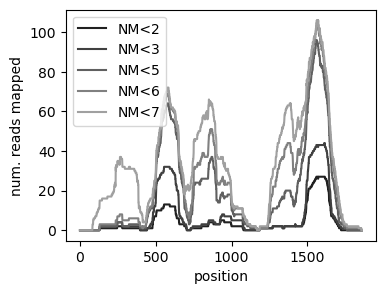

In [20]:
BOWTIE_DIR = '../data/sr-vp/bowtie'

sample_id = 'env_80cm_2018_illumina_1'
path = os.path.join(BOWTIE_DIR, f'{sample_id}.bam')


def plot_mapping(path, ref_id=None, func=np.sum, metric:str='mapped', ax=None, label=None, max_nm=7, read_length=150):


    figure_df = BamFile.from_file(path).to_df(ref_id=ref_id)
    figure_df['mapped'] = (~figure_df.unmapped).astype(int)
    figure_df = figure_df[figure_df.NM <= max_nm].copy()

    ref_length = figure_df.ref_length.iloc[0]
    positions = np.arange(ref_length)
    values = np.zeros((len(figure_df), len(positions)))

    for i, row in enumerate(figure_df.itertuples()):
        start = row.position
        stop = min(start + 150, ref_length)
        values[i, start:stop] = getattr(row, metric)

    values = func(values, axis=0)
    ax.plot(positions, values, label=label)
    ax.set_xlabel('position')

    stats = dict()
    stats['coverage'] = (read_length * len(figure_df)) / ref_length
    stats['variance'] = np.var(values)
    stats['coefficient_of_variance'] = np.sqrt(stats['variance']) / stats['coverage']
    stats['read_count'] = figure_df.mapped.sum()
    stats['fraction_covered'] = (values > 0).mean()
    return stats


fig, ax = plt.subplots(figsize=(4, 3))

for max_nm in [1, 2, 4, 5, 6]:
    # stats = plot_mapping(path, ref_id='mp_0', label=f'NM<{max_nm + 1}', ax=ax, max_nm=max_nm, metric='NM', func=np.mean)
    stats = plot_mapping(path, ref_id='mp_0', label=f'NM<{max_nm + 1}', ax=ax, max_nm=max_nm)
    print(f'NM < {max_nm + 1}:', stats)
ax.legend()
ax.set_ylabel('num. reads mapped')
plt.show()


In [21]:
# coverm contig --bam-files /home/philippar/sr-vp/bbmap/*bam --methods length count mean trimmed_mean covered_fraction > /home/philippar/sr-vp/coverm/community.tsv
# coverm contig --include-secondary --bam-files /home/philippar/sr-vp/bbmap/*bam --methods length count mean trimmed_mean covered_fraction > /home/philippar/sr-vp/coverm/community.tsv

In [59]:


# min_covered_bases_fraction = 0.8
# min_read_count = 5

# STATS_FIELDS = ['file_path', 'format', 'type', 'num_seqs', 'sum_len', 'min_len', 'avg_len', 'max_len']
# stats_df = pd.concat([pd.read_csv(path, names=STATS_FIELDS, sep=r'\s+', header=0) for path in glob.glob('../data/sr-vp/stats/*')])
# stats_df['file_name'] = stats_df.file_path.apply(os.path.basename)
# stats_df['num_seqs'] = stats_df.num_seqs.str.replace(',', '').astype(int)



In [ ]:
# First would like to check the coverm/bbmap-predicted coverages against the ones reported in ggkbase. 
GGKBASE_CONTIG_ID_TO_GENOME_ID_MAP = {'_'.join(ggkbase_gene_id.split('_')[:-1]):f'mp_{cluster_id}' for ggkbase_gene_id, cluster_id in cluster_id_map.items()} # Only the Methanoperedens.

GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP = SRVP_SAMPLE_METADATA_DF[~SRVP_SAMPLE_METADATA_DF.ggkbase_sample_id.isnull()].set_index('ggkbase_sample_id').sample_id.to_dict()
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP = {ggkbase_sample_id.replace('.', '_'):sample_id for ggkbase_sample_id, sample_id in GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP.items()}
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_0-2'] = 'env_2cm_2017_illumina' # 'SR-VP_0-2cm_Biohub_180515'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_4-6'] = 'env_6cm_2017_illumina' # 'SR-VP_4-6cm_Biohub_180515'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_72_4B_1_05m_2_METASPADES'] = 'env_105cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_75_5A_0_95m_2_METASPADES'] = 'env_95cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_81_5A_0_75m_2_METASPADES'] = 'env_75cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_87_5B_1_2m_2_METASPADES'] = 'env_120cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['Methanoperedens_44_19-type_SR-VP_26_10_2019_1_100cm_part'] = 'env_100cm_2019_illumina_1'
# GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SRVP19_trench_C_20cm_viral_megahit'] Missing
# GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SRVP19_trench_A_40cm-2_viral_idba'] Missing


get_ggkbase_sample_id = lambda ggkbase_contig_id : ggkbase_contig_id.split('_scaffold_')[0] if ('scaffold' in ggkbase_contig_id) else '_'.join(ggkbase_contig_id.split('_')[:-1])

mp_rps3_contigs_df = load_mp_rps3_contigs()[['coverage']]
mp_rps3_contigs_df = mp_rps3_contigs_df[~mp_rps3_contigs_df.index.str.contains('PACBIO', case=False)].copy()
mp_rps3_contigs_df['ggkbase_sample_id'] = [get_ggkbase_sample_id(ggkbase_contig_id) for ggkbase_contig_id in mp_rps3_contigs_df.index]
mp_rps3_contigs_df['sample_id'] = mp_rps3_contigs_df.ggkbase_sample_id.map(GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP)
mp_rps3_contigs_df['contig_id'] = mp_rps3_contigs_df.index.map(GGKBASE_CONTIG_ID_TO_GENOME_ID_MAP)
mp_rps3_contigs_df = mp_rps3_contigs_df.reset_index(names=['ggkbase_contig_id'])
mp_rps3_contigs_df = mp_rps3_contigs_df.merge(coverm_df, on=['sample_id', 'contig_id'], how='inner') #, validate='one_to_one')


In [ ]:
# min_num_samples = 3

# figure_df = coverm_df.copy()
# figure_df = figure_df[figure_df.contig_id.str.startswith('mp') | figure_df.contig_id.str.startswith('bz')].copy()
# figure_df = figure_df.pivot(index='contig_id', columns='sample_id', values='rpkm').fillna(0)
# # figure_df =  pd.DataFrame(np.where(figure_df < min_coverage, 0, 1), index=figure_df.index, columns=figure_df.columns)
# # figure_df[figure_df < min_coverage] = 0

# # print(f'Samples with no organism over the {min_coverage}x detection limit:', ' '.join(figure_df.columns[figure_df.T.sum(axis=1) == 0]))
# print(f'Number of organisms not detected in at least {min_num_samples} samples:', ((figure_df > 0).sum(axis=1) < min_num_samples).sum())
# # print(f'Organisms not found in at least {min_num_samples} samples:', ' '.join(figure_df[figure_df.sum(axis=1) < min_num_samples].index))

# figure_df = figure_df[(figure_df > 0).sum(axis=1) >= min_num_samples].copy()
# figure_df = np.log1p(figure_df)

# genome_order = get_order((figure_df.values > 0).astype(int), index=figure_df.index.values)
# sample_order = get_order((figure_df.values > 0).astype(int).T, index=figure_df.columns.values)
# # cmap = ListedColormap(['white', 'darkseagreen', 'steelblue'])
# # Replace values according to organism category (ECE or Methanoperedens). 
# # figure_df[figure_df.index.str.startswith('mp')] =  figure_df[figure_df.index.str.startswith('mp')].replace(1, 2)
# # figure_df[~figure_df.index.str.startswith('mp')] =  figure_df[~figure_df.index.str.startswith('mp')].replace(1, 1)

# fig, ax = plt.subplots(figsize=np.array(figure_df.shape)[::-1] / 3)
# figure_df = figure_df.loc[genome_order, sample_order]
# figure_df[figure_df == 0] = np.nan 

# sns.heatmap(figure_df, cbar=False, cmap='Blues', linecolor='white', linewidths=1)
# ax.set_ylabel('')
# ax.set_xlabel('')
# plt.show()

# # There should be a Methanoperedens with around 6x coverage, SR-VP_05_06_2024_N_bottom, in SR-VP_05_06_2024_N_bottom. 
# # SR-VP_05_06_2024_N_bottom_Black_host_Methanoperedens_44_7
# # Which one is the confirmed Betazoid host? Seems to be mp_10 (SRVP18_trench_2_45cm_scaffold_74960_2 representative, 99% match to SR-VP_Bioreactor_ck_bot_05_17_2025_Black_host_Methanoperedens_44_40)

In [ ]:
# rep_gene_ids = mp_reps_rps3_df.gene_id.unique() # The representative gene IDs. 
# gene_id_to_genome_id_map =  mp_reps_rps3_df.reset_index(drop=False).set_index('gene_id').genome_id.to_dict()
# genome_ids = ['mp_0', 'mp_17', 'mp_37']
# # Re-load the alignment DataFrame and obtain the percent identity between representatives. 


# cmap = plt.cm.Blues.copy()
# cmap.set_bad(color='gray')

# figure_df = pd.read_csv('../data/sr-vp/mp_rps3.tsv', sep='\t', names=MMSEQS_SEARCH_FIELDS.split(','))
# figure_df = figure_df[figure_df['query'].isin(rep_gene_ids) & figure_df['target'].isin(rep_gene_ids)].copy()
# figure_df['query_genome_id'] = figure_df['query'].map(gene_id_to_genome_id_map)
# figure_df['target_genome_id'] = figure_df['target'].map(gene_id_to_genome_id_map)
# figure_df = figure_df.pivot(index='query_genome_id', columns='target_genome_id', values='fident')

# # Matrix is not symmetric automatically, not completely sure why. 
# for i, j in itertools.product(range(len(figure_df)), range(len(figure_df))):
#     fidents = [figure_df.iloc[i, j], figure_df.iloc[j, i]]
#     fidents = [fident for fident in fidents if (not np.isnan(fident))]
#     if len(fidents) == 0:
#         continue 

#     figure_df.iloc[i, j] = max(fidents)
#     figure_df.iloc[j, i] = max(fidents)

# fig, ax = plt.subplots(figsize=(25, 25))

# sns.heatmap(figure_df, cmap=cmap, ax=ax, annot=True, cbar=False, linecolor='black', linewidth=0.7)
# ax.set_xlabel('')
# ax.set_ylabel('')

# for location, spine in ax.spines.items():
#     ax.spines[location].set_visible(True)

# plt.show()


# fig, axes = plt.subplots(figsize=(8, 4), ncols=2)

# ax = axes[0]
# figure_df = list()
# figure_df += [bam_df[bam_df.mp_0_mapped].assign(category='mp_0-mp_0 : mp_0').rename(columns={'mp_0_edit_distance':'edit_distance'})]
# figure_df += [bam_df[bam_df.mp_0_mapped].assign(category='mp_0-mp_0 : mp_reps').rename(columns={'mp_reps_edit_distance':'edit_distance'})]
# figure_df += [bam_df[bam_df.mp_reps_mapped].assign(category='mp_0-mp_reps : mp_reps').rename(columns={'mp_reps_edit_distance':'edit_distance'})] 
# figure_df += [bam_df[bam_df.mp_reps_mapped].assign(category='mp_0-mp_reps : mp_0').rename(columns={'mp_0_edit_distance':'edit_distance'})] 
# figure_df = pd.concat(figure_df).reset_index()

# sns.ecdfplot(figure_df, x='edit_distance', hue='category', stat='count', palette='Grays', ax=ax)
# ax.get_legend().set_title('')
# ax.set_xlim(xmin=0, xmax=30)
# ax.set_ylabel('count')
# ax.set_xlabel('edit distance')

# ax = axes[1]

# figure_df = coverm_dfs['mp_reps'].copy()
# sns.kdeplot(figure_df, x='coefficient_of_variance', color='gray')

# mp_0_cv = coverm_dfs['mp_0'].coefficient_of_variance.iloc[0] # Coefficient of variance for the reads mapped to mp_0 with the mp_reps reference. 
# ax.axvline(x=mp_0_cv, ls='--', color='steelblue', label='mp_0-mp_reps : mp_reps')

# mp_0_cv = coverm_dfs['mp_reps'][coverm_dfs['mp_reps'].contig_id == 'mp_0'].coefficient_of_variance.iloc[0] # Coefficient of variance for the reads mapped to mp_0 with the mp_0 reference. 
# ax.axvline(x=mp_0_cv, ls='--', color='darkseagreen', label='mp_0-mp_0 : mp_0')

# # It seems as though the variability is higher in the mp_0 only sample, suggesting that the full mapping might be slightly better. 

# ax.legend()

# ax.set_ylabel('density')
# ax.set_xlabel(r'coefficient of variance ($\frac{\sigma}{\mu}$)')

# fig.tight_layout
# plt.show()

# # Where are the reads going which had mapped to mp_0 when mp_0 was the only reference?
# print('Where do the reads mapped to mp_0 in the mp_0_rps3 mapping get placed in the mp_reps_rps3 mapping?')
# for row in bam_df[bam_df.mp_0_mapped].mp_reps_ref_id.value_counts().reset_index().itertuples():
#     print(f'{row.mp_reps_ref_id}\t{row.count}')

